# Détection du changement de la surface en eau du lac Trou Caiman (Haiti)

L'objectif de ce notebook est de presenter une methode qui permet d'estimer le changement de la surface en eau d'un lac en comparant les images satellitaires observées à 2 dates differentes.
Pour estimer ce changement nous allons utiliser deux images du satellite Sentinel-2 de l'ESA (European Space Agency).
Nous allons calculer le Normalize Difference Water Index (NDWI) ou indice d’eau par différence normalisée pour chacune de ces images et comparer les resultats obtenus.

Le NDWI (McFeeters en 1996) est utilisé principalement pour détecter et surveiller de faibles changements de la teneur en eau aux bassins d’eau.      En exploitant les longueurs d'ondes proche infrarouge (Near Infrared) et le vert visible (Green), le NDWI permet d’améliorer la détection des bassins d’eau sur les images satellitaires.  

L'equation pour le calcul de NDWI à partir des images satellitaires sentinel-2 est :
NDWI = (Band 3 - Band 8) / (Band 3 + Band 8)

Le vert visible maximise la capacité de réflexion de la surface de l’eau. Le proche infrarouge minimise la capacité de réflexion de la surface de l'eau.
Ce contraste est mis à profit pour calculer le NDWI.

La valeur de l'indice NDWI varie entre -1 et 1. L'interprétation des valeurs NDWI peut varier selon l'application et le type d'environnement étudié.
Pour la détection des plans d'eau, l'une des principales applications de l'indice NDWI, les valeurs de l'indice NDWI correspondent approximativement aux plages suivantes :
Les valeurs de l'indice NDWI correspondent approximativement aux plages suivantes :
+ 0.2 - 1    : Indiquent généralement des plans d'eau clairs et ouverts.
+ 0.0 - 0.2  : Peuvent représenter des eaux peu profondes, des zones humides ou des zones à forte humidité du sol.
+ -0.3 - 0.0 : Indiquent généralement une sécheresse modérée, surfaces non aqueuses
+ -1 - -0.3  : Indiquent généralement une sécheresse, surfaces non aqueuses

McFEETERS, S. K. (1996). The use of the Normalized Difference Water Index (NDWI) in the delineation of open water features. International Journal of Remote Sensing, 17(7), 1425–1432. https://doi.org/10.1080/01431169608948714
###### 
###### Préparé par : Renaldo Sauveur, PhD
###### Date : Février 2026

In [ ]:
!git clone https://github.com/Dotido10/Trou_Caiman.git

### Installation des packages

In [1]:
!pip install leafmap geemap ipyleaflet

### Importation des packages

In [2]:
import math
import rasterio
import rasterio.plot
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import leafmap.foliumap as leafmap 
import matplotlib.colors as mcolors

### Importation des images satellitaires

In [3]:
image_file_01 = "T18QYF_20250825T152659_B03_10m_clipped.tif"
image_file_02 = "T18QYF_20250825T152659_B08_10m_clipped.tif"
image_file_03 = "T18QYF_20251228T152701_B03_10m_clipped.tif"
image_file_04 = "T18QYF_20251228T152701_B08_10m_clipped.tif"

RGB_aout = "T18QYF_20250825T152659_TCI_10m_clipped.tif"
RGB_decembre = "T18QYF_20251228T152701_TCI_10m_clipped.tif"

In [4]:
# Ouverture du fichier image
with rasterio.open(RGB_aout) as src:
    rgb = src.read([1, 2, 3]).astype("float32")
    nodata = src.nodata

rgb = rgb / np.nanmax(rgb)  # normalize
rgb = np.moveaxis(rgb, 0, -1)  # (bands, rows, cols) → (rows, cols, bands)


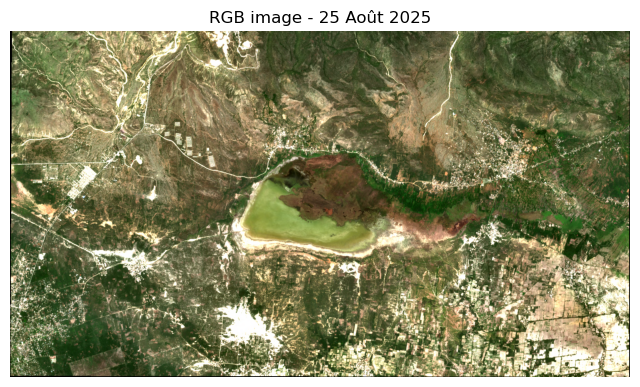

In [5]:
# Affichage du fichier image

plt.figure(figsize=(8, 8))
plt.imshow(rgb)
plt.title("RGB image - 25 Août 2025")
plt.axis("off")
plt.show()

In [6]:
# Ouverture du fichier image

with rasterio.open(RGB_decembre) as src:
    rgb = src.read([1, 2, 3]).astype("float32")
    nodata = src.nodata

rgb = rgb / np.nanmax(rgb)  # normalize
rgb = np.moveaxis(rgb, 0, -1)  # (bands, rows, cols) → (rows, cols, bands)

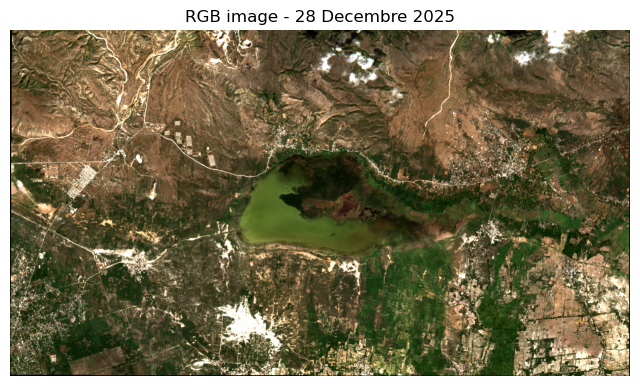

In [7]:
# Affichier du fichier image

plt.figure(figsize=(8, 8))
plt.imshow(rgb)
plt.title("RGB image - 28 Decembre 2025")
plt.axis("off")
plt.show()

In [8]:
# Affichier des deux fichiers image

m = leafmap.Map()

m.add_raster(
    RGB_aout, 
    layer_name="RGB Aout",
    position="left",
)
m.add_raster(
    RGB_decembre, 
    layer_name="RGB Decembre",
    position="right",
)

m.split_map()
m

### Calcul de NDWI pour l'image du mois d'août

In [9]:
# Ouverture du fichier image

with rasterio.open(image_file_02) as nir_src:
    nir = nir_src.read(1).astype("float32")
    profile = nir_src.profile

with rasterio.open(image_file_01) as gre_src:
    gre = gre_src.read(1).astype("float32")

In [10]:
# remplacement des no data par 0
nir[nir == 0] = np.nan
gre[gre == 0] = np.nan

# calcul de la reflectance (DN/10000)
nir /= 10000.0
gre /= 10000.0

In [11]:
# Calculde NDWI

ndwi = (gre - nir) / (gre + nir)

In [12]:
ndwi = np.clip(ndwi, -1, 1)

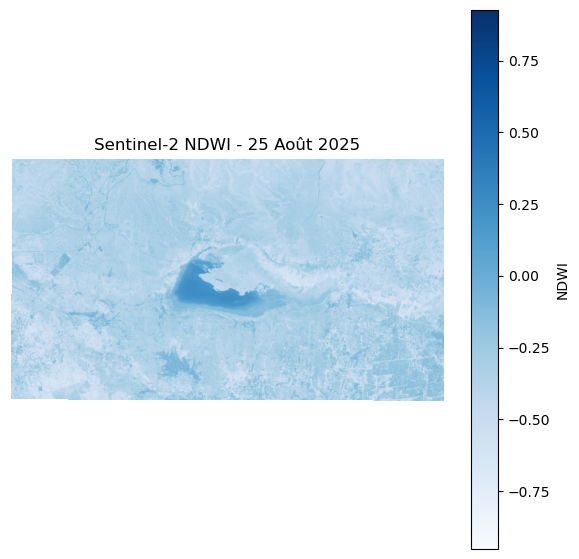

In [13]:
# Affichage du résultat

plt.figure(figsize=(7,7))
plt.imshow(ndwi, cmap="Blues")
plt.colorbar(label="NDWI")
plt.title("Sentinel-2 NDWI - 25 Août 2025")
plt.axis("off")
plt.show()

In [14]:
# Création de l'image binaire (eau / non-eau)

water_mask_aout = ndwi > 0.1

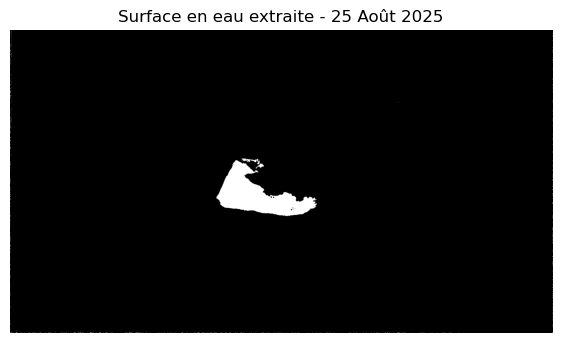

In [15]:
# Affichage du résultat

plt.figure(figsize=(7,7))
plt.imshow(water_mask_aout, cmap="gray")
plt.title("Surface en eau extraite - 25 Août 2025")
plt.axis("off")
plt.show()

In [16]:
# Sauvegarde du fichier image binaire

profile.update(
    dtype=rasterio.uint8,
    count=1,
    nodata=0,
    compress="lzw"
)

with rasterio.open("Surface_En_Eau_25_Août_2025.tif", "w", **profile) as dst:
    dst.write(water_mask_aout.astype("uint8"), 1)


### Calcul de NDWI pour l'image du mois de decembre

In [17]:
# Ouverture du fichier image

with rasterio.open(image_file_04) as nir_src:
    nir = nir_src.read(1).astype("float32")
    profile = nir_src.profile

with rasterio.open(image_file_03) as gre_src:
    gre = gre_src.read(1).astype("float32")

In [18]:
# remplacement des no data par 0
nir[nir == 0] = np.nan
gre[gre == 0] = np.nan

# calcul de la reflectance (DN/10000)
nir /= 10000.0
gre /= 10000.0

In [19]:
# Calcul de NDWI

ndwi = (gre - nir) / (gre + nir)

In [20]:
ndwi = np.clip(ndwi, -1, 1)

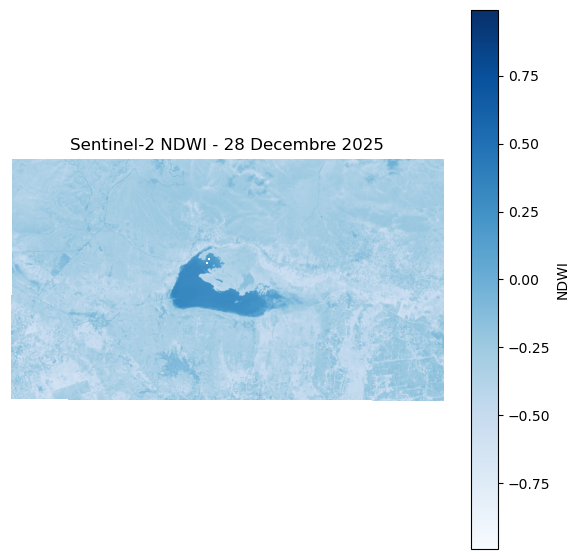

In [21]:
# Affichage du résultat

plt.figure(figsize=(7,7))
plt.imshow(ndwi, cmap="Blues")
plt.colorbar(label="NDWI")
plt.title("Sentinel-2 NDWI - 28 Decembre 2025")
plt.axis("off")
plt.show()

In [22]:
# Création de l'image binaire (eau / non-eau)

water_mask_decembre = ndwi > 0.1

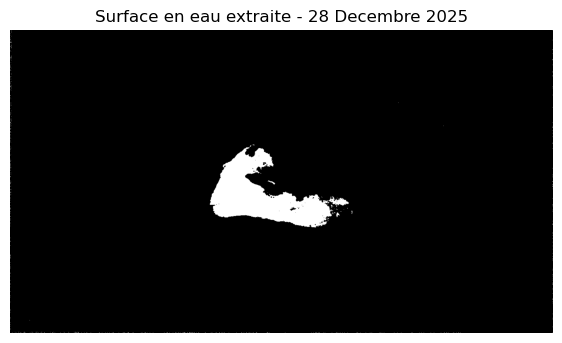

In [23]:
# Affichage du résultat

plt.figure(figsize=(7,7))
plt.imshow(water_mask_decembre, cmap="gray")
plt.title("Surface en eau extraite - 28 Decembre 2025")
plt.axis("off")
plt.show()

In [24]:
# Sauvegarde du fichier image binaire

profile.update(
    dtype=rasterio.uint8,
    count=1,
    nodata=0,
    compress="lzw"
)

with rasterio.open("Surface_En_Eau_28_Decembre_2025.tif", "w", **profile) as dst:
    dst.write(water_mask_decembre.astype("uint8"), 1)

### Comparaison des NDWI calculés

In [25]:
# Calcul de la difference entre les deux images binaires

diff_water_mask = water_mask_decembre.astype(int) - water_mask_aout.astype(int)


In [26]:
# Sauvegarde du fichier image binaire

profile.update(
    dtype=rasterio.uint8,
    count=1,
    nodata=0,
    compress="lzw"
)

with rasterio.open("Difference_Entre_Aout_Decembre_2025.tif", "w", **profile) as dst:
    dst.write(diff_water_mask.astype("uint8"), 1)

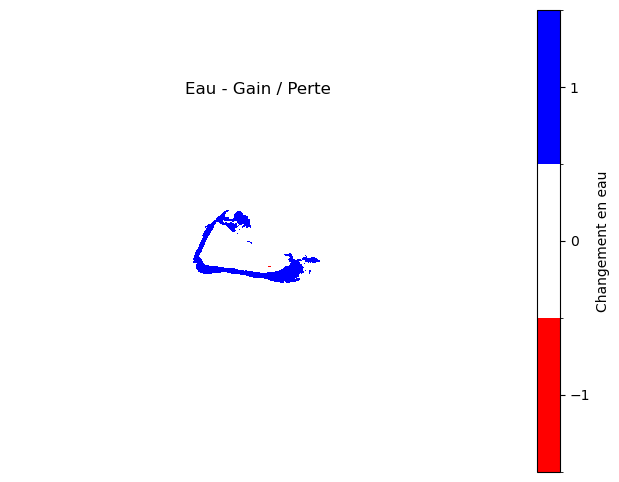

In [27]:
# Definition des couleurs: perte (rouge), pas de changement (blanc), gain (bleu)
cmap = mcolors.ListedColormap(["red", "white", "blue"])

# Limites pour -1, 0, +1
bounds = [-1.5, -0.5, 0.5, 1.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Affichage du résultat
plt.figure(figsize=(8, 6))
plt.imshow(diff_water_mask, cmap=cmap, norm=norm)
plt.colorbar(ticks=[-1, 0, 1], label="Changement en eau")
plt.title("Eau - Gain / Perte")
plt.axis("off")
plt.show()

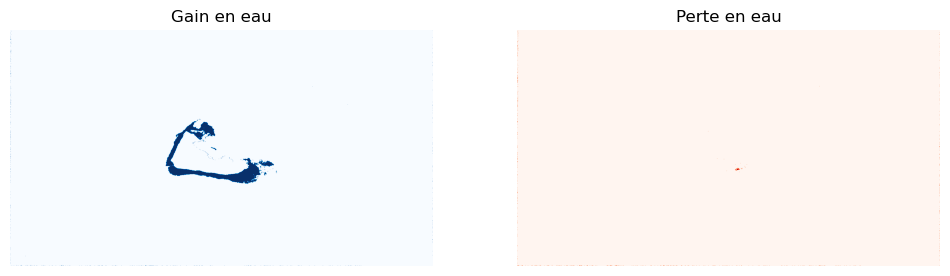

In [28]:
# Affichage du résultat

gain = diff_water_mask == 1
perte = diff_water_mask == -1

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gain, cmap="Blues")
plt.title("Gain en eau")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(perte, cmap="Reds")
plt.title("Perte en eau")
plt.axis("off")

plt.show()

In [29]:
gain_pixels = (diff_water_mask == 1).sum()
perte_pixels = (diff_water_mask == -1).sum()

print("Gain pixels:", gain_pixels)
print("Perte pixels:", perte_pixels)


Gain pixels: 17542
Perte pixels: 806


In [30]:
pixel_size = 10   # mètre
pixel_surface = pixel_size ** 2


In [31]:
gain_surface_m2 = gain_pixels * pixel_surface
perte_surface_m2 = perte_pixels * pixel_surface

net_change_m2 = gain_surface_m2 - perte_surface_m2

In [32]:
gain_km2 = gain_surface_m2 / 1e6
perte_km2 = perte_surface_m2 / 1e6
net_km2  = net_change_m2 / 1e6

print(f"Gain en surface en eau : {gain_km2:.3f} km²")
print(f"Perte en surface en eau  : {perte_km2:.3f} km²")
print(f"Changement net  : {net_km2:.3f} km²")


Gain en surface en eau : 1.754 km²
Perte en surface en eau  : 0.081 km²
Changement net  : 1.674 km²


### Superposition des surfaces en eau delimitée

#### Affichage de la difference des surfaces en eau delimitées

In [33]:
gain_path = r"Difference_Entre_Aout_Decembre_2025.tif"

m = leafmap.Map()

# Sentinel Août 2025
m.add_raster(
    RGB_aout,
    layer_name="Sentinel-2 RGB 2025"
)

# Gain 
m.add_raster(
    gain_path,
    layer_name="Gain en eau",
    cmap="Blues",
    vmin=0,
    vmax=1,
    opacity=0.6
)

m

#### Superposition des deux surfaces delimitées

In [34]:
aout_path = r"Surface_En_Eau_25_Août_2025.tif"
decembre_path = r"Surface_En_Eau_28_Decembre_2025.tif"

m = leafmap.Map()

# Gain 
m.add_raster(
    aout_path,
    layer_name="Aout eau",
    cmap="Blues",
    vmin=0,
    vmax=1,    
)

# Gain 
m.add_raster(
    decembre_path,
    layer_name="Decembre eau",
    cmap="Blues",
    vmin=0,
    vmax=1,
    opacity=0.5
)

m